# Task 1 - MLP on California Housing


In [1]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
TARGET = "MedHouseVal"
ORIGINAL_FEATURES = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]

ROOT_DIR = Path.cwd() if (Path.cwd() / "california_housing.csv").exists() else Path.cwd().parent
DATA_PATH = ROOT_DIR / "california_housing.csv"

# Important experiment choices
TARGET_CAP_VALUE = 5.0
TRAIN_SPLIT_RATIO = 0.70
VALIDATION_SPLIT_RATIO = 0.15
TEST_SPLIT_RATIO = 0.15
IQR_OUTLIER_MULTIPLIER = 1.5
STRONG_CORRELATION_THRESHOLD = 0.70
FEATURE_RELATIONSHIP_QUANTILE = 0.99

# Model and training choices
BASELINE_HIDDEN_DIMS = (128, 64, 32)
ENHANCED_HIDDEN_DIMS = (160, 96, 48)
DEFAULT_DROPOUT = 0.10
DEFAULT_LEARNING_RATE = 1e-3
TRAIN_BATCH_SIZE = 1024
MAX_EPOCHS = 260
EARLY_STOPPING_PATIENCE = 25
WEIGHT_DECAY = 1e-4
MIN_VALIDATION_LOSS_DELTA = 1e-6
PREDICTION_BATCH_SIZE = 512
DEVICE = torch.device("cpu")

# Feature engineering choices
FEATURE_EPSILON = 1e-6
LOS_ANGELES_LATITUDE = 34.0522
LOS_ANGELES_LONGITUDE = -118.2437
SAN_FRANCISCO_LATITUDE = 37.7749
SAN_FRANCISCO_LONGITUDE = -122.4194

# Error-analysis choices
HIGH_VALUE_THRESHOLD = 4.5
LOW_VALUE_THRESHOLD = 1.0
ABSOLUTE_ERROR_P90_QUANTILE = 0.90
ABSOLUTE_ERROR_P95_QUANTILE = 0.95
WORST_PREDICTION_COUNT = 20


def set_reproducibility(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



def save_current_figure() -> None:
    plt.tight_layout()
    plt.show()
    plt.close()


set_reproducibility(SEED)


## 1. Dataset Loading


In [2]:
def load_data() -> pd.DataFrame:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Expected dataset at {DATA_PATH}")
    return pd.read_csv(DATA_PATH)


df = load_data()
expected_columns = set(ORIGINAL_FEATURES + [TARGET])
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing expected columns: {sorted(missing_columns)}")

dataset_overview = pd.DataFrame(
    {
        "value": [
            df.shape[0],
            len(ORIGINAL_FEATURES),
            TARGET,
            int(df.isna().sum().sum()),
            int((df[TARGET] >= TARGET_CAP_VALUE).sum()),
            (df[TARGET] >= TARGET_CAP_VALUE).mean() * 100,
        ]
    },
    index=[
        "number_of_samples",
        "number_of_input_features",
        "target_column",
        "total_missing_values",
        "rows_at_target_cap",
        "percent_at_target_cap",
    ],
)

display(df.head())
display(dataset_overview)
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "missing_count": df.isna().sum()}))


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,value
number_of_samples,20640
number_of_input_features,8
target_column,MedHouseVal
total_missing_values,0
rows_at_target_cap,992
percent_at_target_cap,4.806202


,dtype,missing_count
MedInc,float64,0
HouseAge,float64,0
AveRooms,float64,0
AveBedrms,float64,0
Population,float64,0
AveOccup,float64,0
Latitude,float64,0
Longitude,float64,0
MedHouseVal,float64,0


### Answer: Dataset Loading

The dataset contains 20,640 rows, 8 original input features, and the regression target `MedHouseVal`. All columns are numeric and the notebook reports 0 missing values, so no imputation is needed. The target is measured in hundreds of thousands of dollars and is top-coded: 992 rows, or 4.81%, are at or above 5.0, which makes the highest-value districts harder to model exactly.


## 2. Exploratory Data Analysis


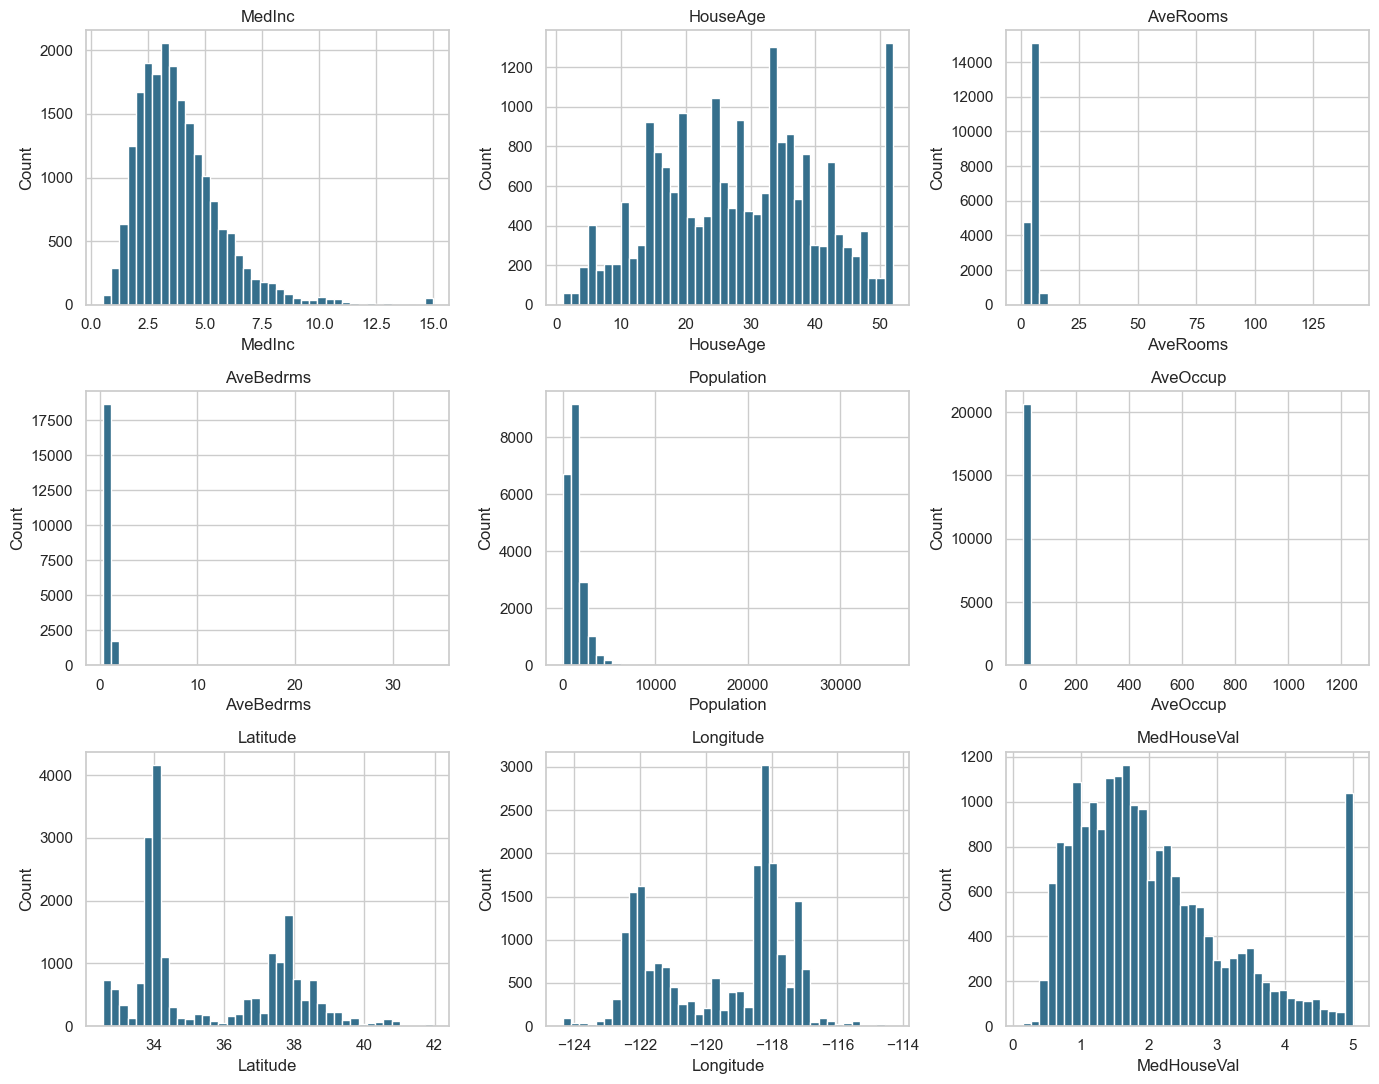

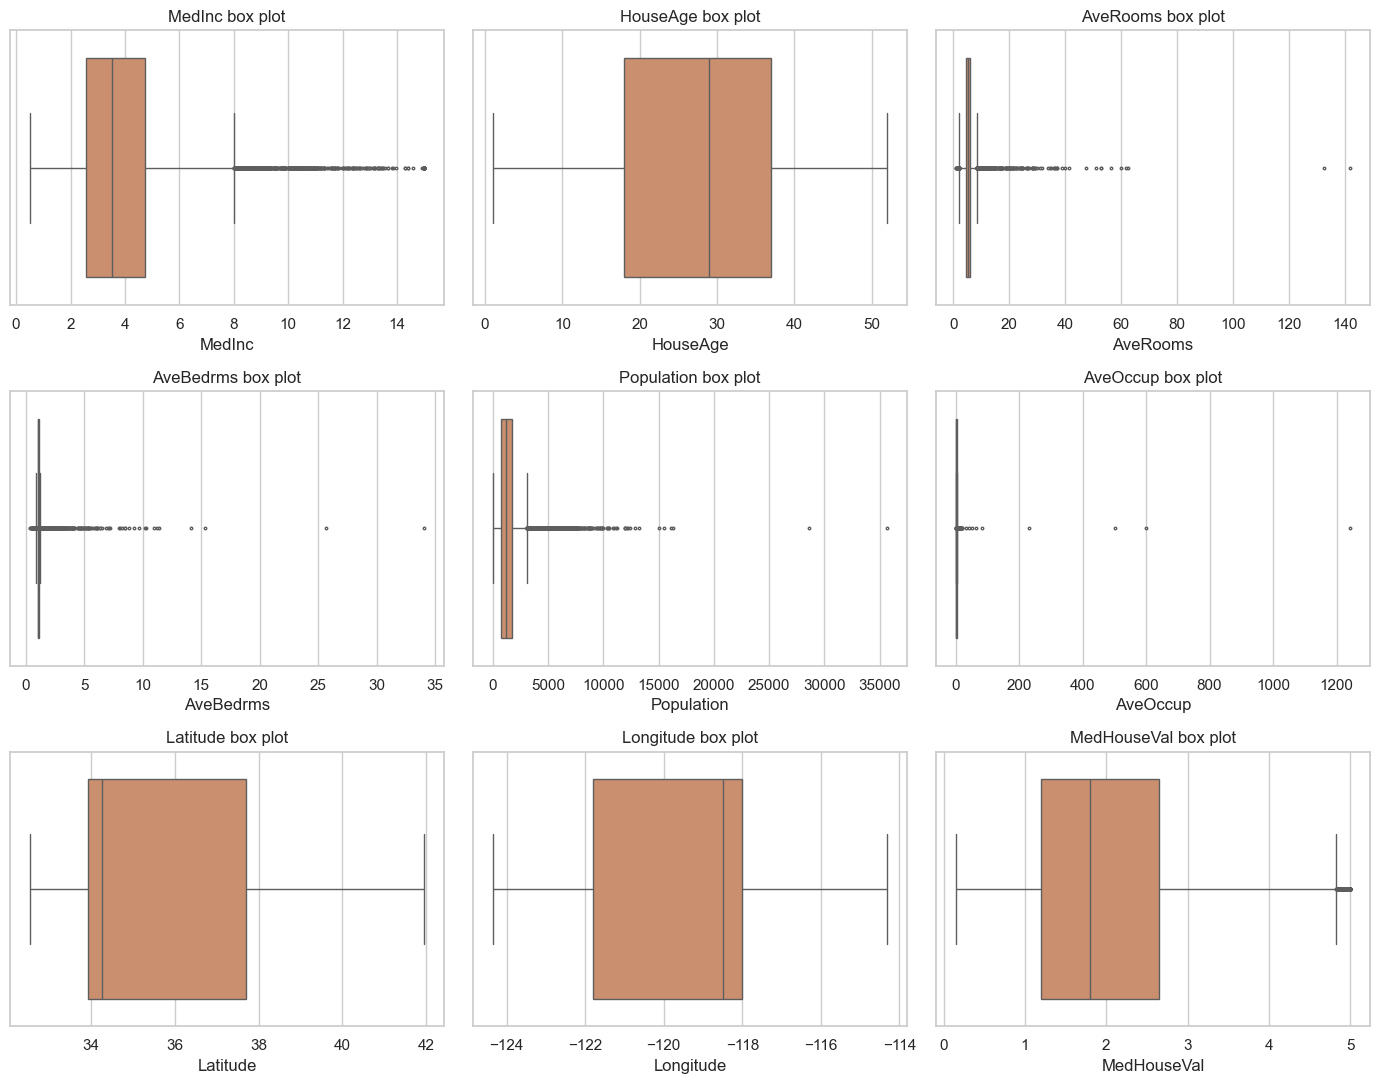

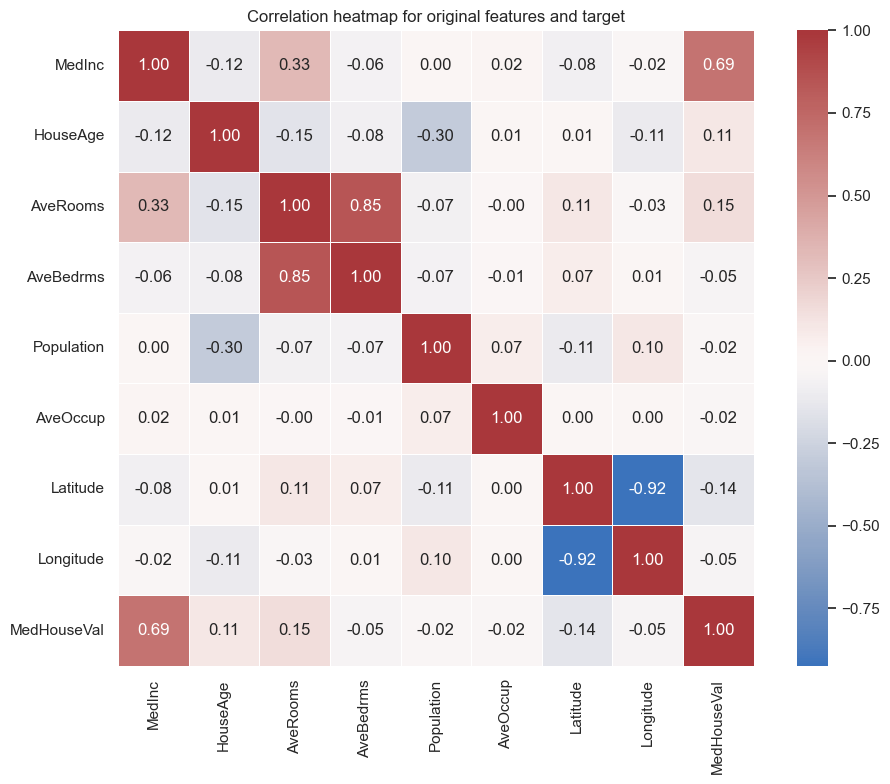

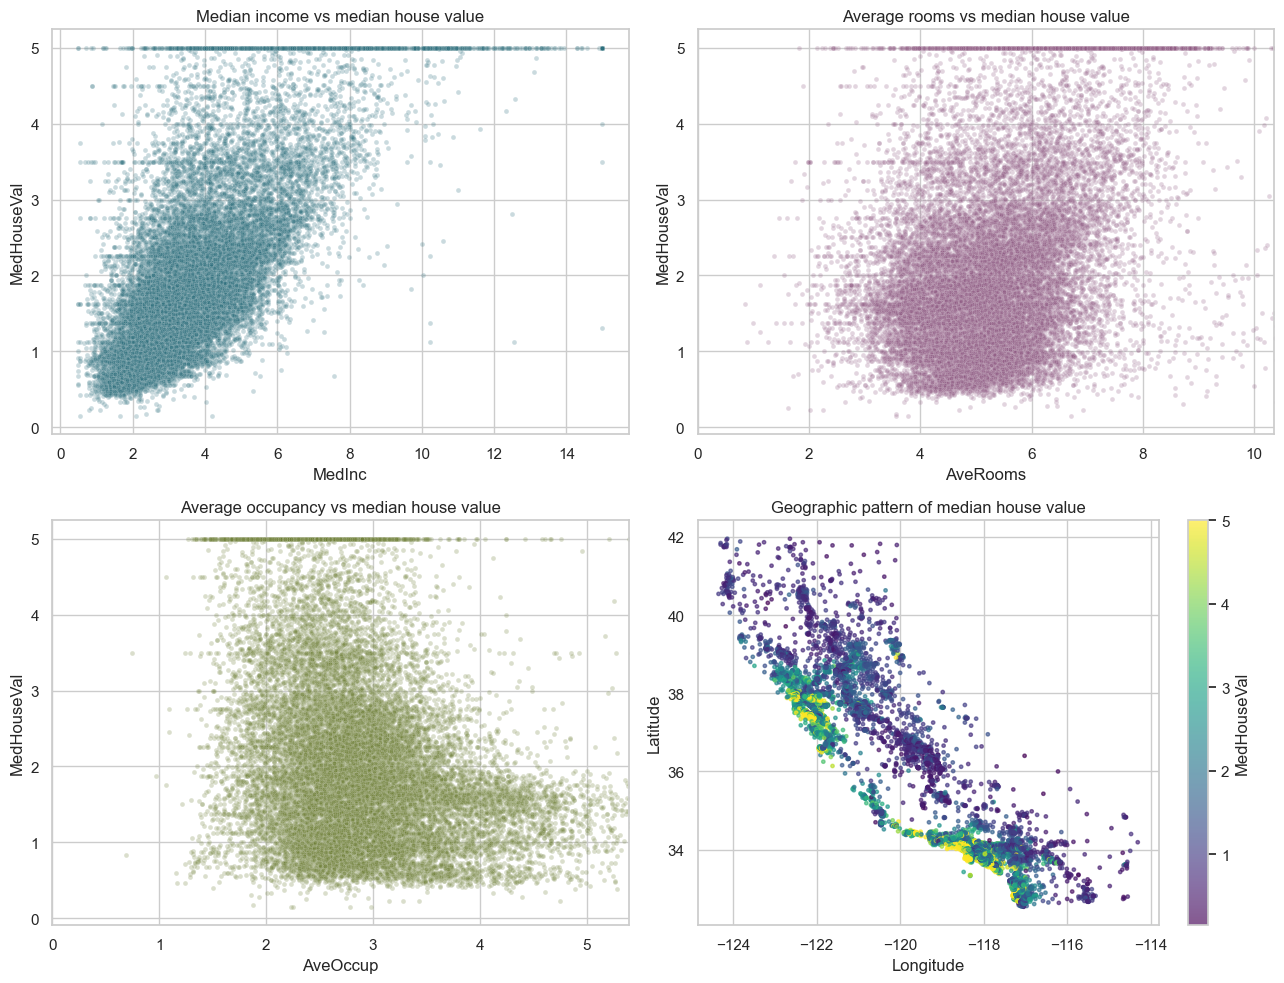

Statistical summary


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
HouseAge,20640.0,28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,20640.0,5.4290,2.4742,0.8462,4.4407,5.2291,6.0524,141.9091
AveBedrms,20640.0,1.0967,0.4739,0.3333,1.0061,1.0488,1.0995,34.0667
Population,20640.0,1425.4767,1132.4621,3.0000,787.0000,1166.0000,1725.0000,35682.0000
AveOccup,20640.0,3.0707,10.3860,0.6923,2.4297,2.8181,3.2823,1243.3333
Latitude,20640.0,35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
Longitude,20640.0,-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
MedHouseVal,20640.0,2.0686,1.1540,0.1500,1.1960,1.7970,2.6472,5.0000


Target correlations


,correlation_with_target
MedInc,0.6881
AveRooms,0.1519
Latitude,-0.1442
HouseAge,0.1056
AveBedrms,-0.0467
Longitude,-0.0460
Population,-0.0246
AveOccup,-0.0237


Most skewed variables


,skewness
AveOccup,97.6396
AveBedrms,31.3170
AveRooms,20.6979
Population,4.9359
MedInc,1.6467


Largest IQR outlier counts


,iqr_outlier_count
AveBedrms,1424
Population,1196
MedHouseVal,1071
AveOccup,711
MedInc,681


Strongly correlated original feature pairs


,feature_1,feature_2,correlation
0,AveRooms,AveBedrms,0.8476
1,Latitude,Longitude,-0.9247


In [3]:
def compute_eda(df: pd.DataFrame) -> dict[str, object]:
    features = [col for col in df.columns if col != TARGET]
    summary = df.describe().T
    skewness = df[features + [TARGET]].skew().sort_values(ascending=False)
    missing = df.isna().sum()
    q1 = df[features + [TARGET]].quantile(0.25)
    q3 = df[features + [TARGET]].quantile(0.75)
    iqr = q3 - q1
    outlier_counts = ((df[features + [TARGET]] < (q1 - IQR_OUTLIER_MULTIPLIER * iqr)) | (df[features + [TARGET]] > (q3 + IQR_OUTLIER_MULTIPLIER * iqr))).sum()
    corr = df[features + [TARGET]].corr(numeric_only=True)
    target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
    strong_pairs = []
    for i, left in enumerate(features):
        for right in features[i + 1 :]:
            value = corr.loc[left, right]
            if abs(value) >= STRONG_CORRELATION_THRESHOLD:
                strong_pairs.append({"feature_1": left, "feature_2": right, "correlation": float(value)})

    capped_count = int((df[TARGET] >= TARGET_CAP_VALUE).sum())

    return {
        "shape": df.shape,
        "dtypes": {col: str(dtype) for col, dtype in df.dtypes.items()},
        "missing_total": int(missing.sum()),
        "summary": summary,
        "skewness": skewness,
        "outlier_counts": outlier_counts.sort_values(ascending=False),
        "target_correlations": target_corr,
        "strong_feature_pairs": strong_pairs,
        "target_capped_count": capped_count,
        "target_capped_pct": capped_count / len(df) * 100,
    }




def create_eda_plots(df: pd.DataFrame) -> None:
    sns.set_theme(style="whitegrid")
    features = [col for col in df.columns if col != TARGET]

    axes = df[features + [TARGET]].hist(figsize=(14, 11), bins=40, color="#356f8c", edgecolor="white")
    for ax in np.ravel(axes):
        ax.set_xlabel(ax.get_title())
        ax.set_ylabel("Count")
    save_current_figure()

    fig, axes = plt.subplots(3, 3, figsize=(14, 11))
    for ax, col in zip(axes.ravel(), features + [TARGET]):
        sns.boxplot(x=df[col], ax=ax, color="#d98b5f", fliersize=1.8)
        ax.set_title(f"{col} box plot")
        ax.set_xlabel(col)
    save_current_figure()

    plt.figure(figsize=(10, 8))
    corr = df[features + [TARGET]].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=0.4)
    plt.title("Correlation heatmap for original features and target")
    save_current_figure()

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    sns.scatterplot(data=df, x="MedInc", y=TARGET, alpha=0.25, s=12, ax=axes[0, 0], color="#2d6f7d")
    axes[0, 0].set_title("Median income vs median house value")

    sns.scatterplot(data=df, x="AveRooms", y=TARGET, alpha=0.25, s=12, ax=axes[0, 1], color="#8f5a83")
    axes[0, 1].set_xlim(0, df["AveRooms"].quantile(FEATURE_RELATIONSHIP_QUANTILE))
    axes[0, 1].set_title("Average rooms vs median house value")

    sns.scatterplot(data=df, x="AveOccup", y=TARGET, alpha=0.25, s=12, ax=axes[1, 0], color="#6e7f36")
    axes[1, 0].set_xlim(0, df["AveOccup"].quantile(FEATURE_RELATIONSHIP_QUANTILE))
    axes[1, 0].set_title("Average occupancy vs median house value")

    geo = axes[1, 1].scatter(
        df["Longitude"],
        df["Latitude"],
        c=df[TARGET],
        cmap="viridis",
        s=6,
        alpha=0.65,
    )
    axes[1, 1].set_title("Geographic pattern of median house value")
    axes[1, 1].set_xlabel("Longitude")
    axes[1, 1].set_ylabel("Latitude")
    fig.colorbar(geo, ax=axes[1, 1], label=TARGET)
    save_current_figure()

eda = compute_eda(df)
create_eda_plots(df)

eda_summary_table = eda["summary"].round(4)
target_correlation_table = eda["target_correlations"].to_frame("correlation_with_target").round(4)
skewness_table = eda["skewness"].head(5).to_frame("skewness").round(4)
outlier_table = eda["outlier_counts"].head(5).to_frame("iqr_outlier_count")
strong_pairs_table = pd.DataFrame(eda["strong_feature_pairs"])
if not strong_pairs_table.empty:
    strong_pairs_table = strong_pairs_table.round({"correlation": 4})

print("Statistical summary")
display(eda_summary_table)
print("Target correlations")
display(target_correlation_table)
print("Most skewed variables")
display(skewness_table)
print("Largest IQR outlier counts")
display(outlier_table)
print("Strongly correlated original feature pairs")
display(strong_pairs_table if not strong_pairs_table.empty else pd.DataFrame(columns=["feature_1", "feature_2", "correlation"]))


### Answer: Exploratory Data Analysis

`MedInc` has the strongest original linear relationship with `MedHouseVal` (correlation 0.6881), so income is the most important single raw predictor. `Latitude` and `Longitude` also matter because the plots show strong geographic price structure. Several variables are highly right-skewed, especially `AveOccup`, `AveBedrms`, `AveRooms`, and `Population`, and the largest IQR outlier counts occur in `AveBedrms`, `Population`, `MedHouseVal`, `AveOccup`, and `MedInc`. These findings support standardization, validation monitoring, and engineered ratio/log/geographic features.


## 3. Data Preparation


In [4]:
@dataclass
class SplitData:
    x_train: np.ndarray
    x_val: np.ndarray
    x_test: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    scaler: StandardScaler
    feature_names: list[str]




def prepare_split(
    df: pd.DataFrame,
    feature_names: list[str],
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
) -> SplitData:
    x = df[feature_names].to_numpy(dtype=np.float32)
    y = df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x[train_idx]).astype(np.float32)
    x_val = scaler.transform(x[val_idx]).astype(np.float32)
    x_test = scaler.transform(x[test_idx]).astype(np.float32)

    return SplitData(
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
        y_train=y[train_idx],
        y_val=y[val_idx],
        y_test=y[test_idx],
        scaler=scaler,
        feature_names=feature_names,
    )




def make_loaders(split: SplitData, batch_size: int) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = TensorDataset(torch.from_numpy(split.x_train), torch.from_numpy(split.y_train))
    val_ds = TensorDataset(torch.from_numpy(split.x_val), torch.from_numpy(split.y_val))
    test_ds = TensorDataset(torch.from_numpy(split.x_test), torch.from_numpy(split.y_test))

    generator = torch.Generator()
    generator.manual_seed(SEED)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False),
    )

all_indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(all_indices, test_size=(VALIDATION_SPLIT_RATIO + TEST_SPLIT_RATIO), random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=TEST_SPLIT_RATIO / (VALIDATION_SPLIT_RATIO + TEST_SPLIT_RATIO), random_state=SEED)
baseline_split = prepare_split(df, ORIGINAL_FEATURES, train_idx, val_idx, test_idx)
split_table = pd.DataFrame(
    {
        "rows": [len(train_idx), len(val_idx), len(test_idx)],
        "configured_percent": [
            TRAIN_SPLIT_RATIO * 100,
            VALIDATION_SPLIT_RATIO * 100,
            TEST_SPLIT_RATIO * 100,
        ],
        "actual_percent": [
            len(train_idx) / len(df) * 100,
            len(val_idx) / len(df) * 100,
            len(test_idx) / len(df) * 100,
        ],
    },
    index=["train", "validation", "test"],
)
display(split_table.round(2))


,rows,configured_percent,actual_percent
train,14448,70.0,70.0
validation,3096,15.0,15.0
test,3096,15.0,15.0


### Answer: Data Preparation

The data is split once into 14,448 training rows, 3,096 validation rows, and 3,096 test rows, corresponding to 70%/15%/15%. `StandardScaler` is fitted only on the training features and then reused for validation and test features, which avoids data leakage. Scaling is important for an MLP because the input features have very different units and ranges.


## 4. Baseline MLP Model


In [5]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple[int, ...], dropout: float = DEFAULT_DROPOUT) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


display(MLPRegressor(input_dim=len(ORIGINAL_FEATURES), hidden_dims=BASELINE_HIDDEN_DIMS, dropout=DEFAULT_DROPOUT))


MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 5. Model Training


,model,hidden_dims,lr,batch_size,max_epochs,patience,weight_decay,dropout
0,baseline,"(128, 64, 32)",0.001,1024,260,25,0.0001,0.1


,model,best_epoch,best_val_loss,epochs_run,device
0,baseline,260,0.277183,260,cpu


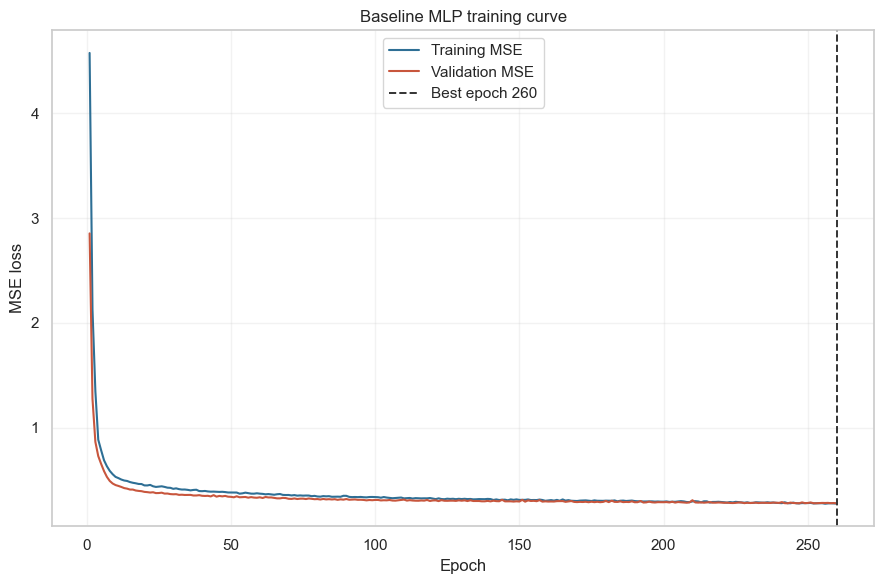

In [6]:
def epoch_loss(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            losses.append(loss.item() * len(xb))
    return float(np.sum(losses) / len(loader.dataset))




def train_model(
    name: str,
    split: SplitData,
    hidden_dims: tuple[int, ...],
    lr: float = DEFAULT_LEARNING_RATE,
    batch_size: int = TRAIN_BATCH_SIZE,
    max_epochs: int = MAX_EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
    weight_decay: float = WEIGHT_DECAY,
    dropout: float = DEFAULT_DROPOUT,
) -> tuple[MLPRegressor, dict[str, object]]:
    device = DEVICE
    model = MLPRegressor(len(split.feature_names), hidden_dims=hidden_dims, dropout=dropout).to(device)
    train_loader, val_loader, _ = make_loaders(split, batch_size=batch_size)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "lr": []}
    best_val_loss = math.inf
    best_epoch = 0
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss = epoch_loss(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss - MIN_VALIDATION_LOSS_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is None:
        raise RuntimeError("Training did not produce a checkpoint state.")
    model.load_state_dict(best_state)
    model.to(device)

    metadata = {
        "name": name,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_run": len(history["epoch"]),
        "checkpoint": "in-memory best validation state",
        "device": str(device),
        "hidden_dims": hidden_dims,
        "learning_rate": lr,
        "batch_size": batch_size,
        "max_epochs": max_epochs,
        "patience": patience,
        "weight_decay": weight_decay,
        "dropout": dropout,
    }
    return model, metadata




def plot_training_curves(metadata: dict[str, object]) -> None:
    history = metadata["history"]
    epochs = history["epoch"]

    plt.figure(figsize=(9, 6))
    plt.plot(epochs, history["train_loss"], label="Training MSE", color="#2e6f95")
    plt.plot(epochs, history["val_loss"], label="Validation MSE", color="#c8563d")
    plt.axvline(metadata["best_epoch"], color="#333333", linestyle="--", linewidth=1.4, label=f"Best epoch {metadata['best_epoch']}")
    plt.title(f"{metadata['name'].title()} MLP training curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(True, alpha=0.25)
    save_current_figure()

baseline_train_params = {
    "hidden_dims": BASELINE_HIDDEN_DIMS,
    "lr": DEFAULT_LEARNING_RATE,
    "batch_size": TRAIN_BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": EARLY_STOPPING_PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DEFAULT_DROPOUT,
}
baseline_config_table = pd.DataFrame([{"model": "baseline", **baseline_train_params}])
display(baseline_config_table)

baseline_model, baseline_meta = train_model("baseline", baseline_split, **baseline_train_params)
baseline_training_result_table = pd.DataFrame(
    [
        {
            "model": baseline_meta["name"],
            "best_epoch": baseline_meta["best_epoch"],
            "best_val_loss": baseline_meta["best_val_loss"],
            "epochs_run": baseline_meta["epochs_run"],
            "device": baseline_meta["device"],
        }
    ]
)
display(baseline_training_result_table)
plot_training_curves(baseline_meta)


### Answer: Baseline Model Training

The baseline model uses only the 8 original features with hidden layers 128 -> 64 -> 32, ReLU activations, dropout 0.10, MSE loss, Adam, batch size 1024, weight decay 0.0001, and early stopping patience 25. Its training and validation losses decrease smoothly and stay close, so there is no strong sign of severe overfitting. The best baseline checkpoint is from epoch 260.


## 6. Feature Engineering


In [7]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    engineered = df.copy()
    eps = FEATURE_EPSILON

    engineered["RoomsPerPerson"] = engineered["AveRooms"] / (engineered["AveOccup"] + eps)
    engineered["BedroomsPerRoom"] = engineered["AveBedrms"] / (engineered["AveRooms"] + eps)
    engineered["RoomsPerBedroom"] = engineered["AveRooms"] / (engineered["AveBedrms"] + eps)
    engineered["IncomePerOccupant"] = engineered["MedInc"] / (engineered["AveOccup"] + eps)
    engineered["PopulationLog"] = np.log1p(engineered["Population"])
    engineered["AveOccupLog"] = np.log1p(engineered["AveOccup"])
    engineered["AveRoomsLog"] = np.log1p(engineered["AveRooms"])
    engineered["LatitudeLongitude"] = engineered["Latitude"] * engineered["Longitude"]
    engineered["LatitudeSquared"] = engineered["Latitude"] ** 2
    engineered["LongitudeSquared"] = engineered["Longitude"] ** 2

    # Approximate distances in degrees to two major high-value coastal job centers.
    engineered["DistanceToLosAngeles"] = np.sqrt((engineered["Latitude"] - LOS_ANGELES_LATITUDE) ** 2 + (engineered["Longitude"] - LOS_ANGELES_LONGITUDE) ** 2)
    engineered["DistanceToSanFrancisco"] = np.sqrt((engineered["Latitude"] - SAN_FRANCISCO_LATITUDE) ** 2 + (engineered["Longitude"] - SAN_FRANCISCO_LONGITUDE) ** 2)
    engineered["ClosestMajorCityDistance"] = engineered[["DistanceToLosAngeles", "DistanceToSanFrancisco"]].min(axis=1)

    return engineered

engineered_df = add_engineered_features(df)
engineered_features = [col for col in engineered_df.columns if col not in df.columns]
enhanced_feature_names = ORIGINAL_FEATURES + engineered_features
enhanced_split = prepare_split(engineered_df, enhanced_feature_names, train_idx, val_idx, test_idx)
engineered_feature_table = pd.DataFrame({"engineered_feature": engineered_features})
display(engineered_feature_table)
display(engineered_df[engineered_features].head())


,engineered_feature
0,RoomsPerPerson
1,BedroomsPerRoom
2,RoomsPerBedroom
3,IncomePerOccupant
4,PopulationLog
5,AveOccupLog
6,AveRoomsLog
7,LatitudeLongitude
8,LatitudeSquared
9,LongitudeSquared


,RoomsPerPerson,BedroomsPerRoom,RoomsPerBedroom,IncomePerOccupant,PopulationLog,AveOccupLog,AveRoomsLog,LatitudeLongitude,LatitudeSquared,LongitudeSquared,DistanceToLosAngeles,DistanceToSanFrancisco,ClosestMajorCityDistance
0,2.732918,0.146591,6.821699,3.257686,5.777652,1.268511,2.077455,-4630.0724,1434.8944,14940.1729,5.526540,0.216606,0.216606
1,2.956683,0.155797,6.418619,3.934606,7.784057,1.134572,1.979364,-4627.2492,1433.3796,14937.7284,5.505479,0.216800,0.216800
2,2.957660,0.129516,7.721045,2.589837,6.208590,1.335596,2.228738,-4626.7840,1432.6225,14942.6176,5.513048,0.194485,0.194485
3,2.283153,0.184458,5.421272,2.214764,6.326149,1.266369,1.919471,-4627.1625,1432.6225,14945.0625,5.520301,0.185301,0.185301
4,2.879645,0.172096,5.810709,1.763125,6.338594,1.157342,1.985385,-4627.1625,1432.6225,14945.0625,5.520301,0.185301,0.185301


### Answer: Feature Engineering

The engineered features add ratios, log transforms, nonlinear geography, and approximate distances to Los Angeles and San Francisco. Ratios such as rooms per person and bedrooms per room summarize household density and room composition, log features reduce the effect of heavy skew, and geographic features expose spatial price patterns that were visible in EDA. These features are reasonable because this is a structured tabular dataset with meaningful domain relationships.


## 7. Enhanced MLP Model


,model,hidden_dims,lr,batch_size,max_epochs,patience,weight_decay,dropout
0,enhanced,"(160, 96, 48)",0.001,1024,260,25,0.0001,0.1


,model,best_epoch,best_val_loss,epochs_run,device
0,enhanced,253,0.250878,260,cpu


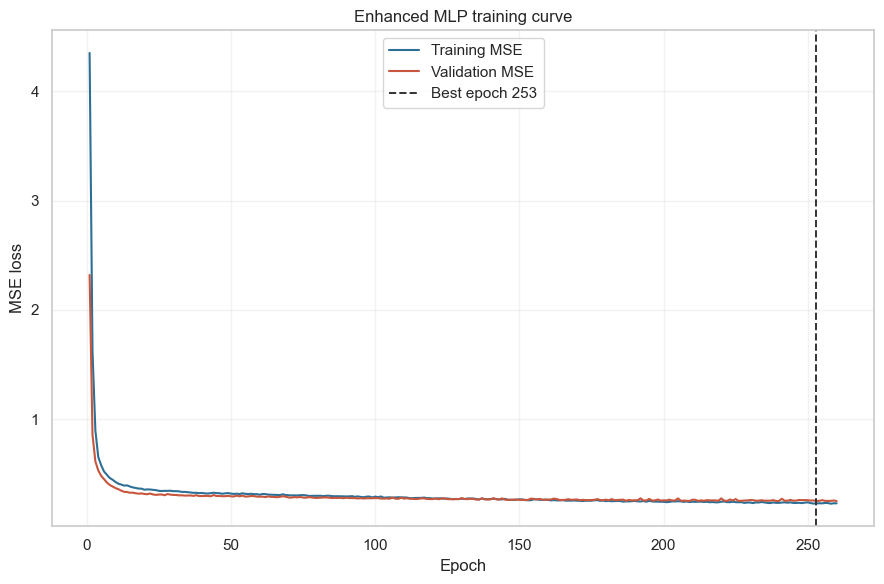

In [8]:
enhanced_train_params = {
    "hidden_dims": ENHANCED_HIDDEN_DIMS,
    "lr": DEFAULT_LEARNING_RATE,
    "batch_size": TRAIN_BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": EARLY_STOPPING_PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DEFAULT_DROPOUT,
}
enhanced_config_table = pd.DataFrame([{"model": "enhanced", **enhanced_train_params}])
display(enhanced_config_table)

enhanced_model, enhanced_meta = train_model("enhanced", enhanced_split, **enhanced_train_params)
enhanced_training_result_table = pd.DataFrame(
    [
        {
            "model": enhanced_meta["name"],
            "best_epoch": enhanced_meta["best_epoch"],
            "best_val_loss": enhanced_meta["best_val_loss"],
            "epochs_run": enhanced_meta["epochs_run"],
            "device": enhanced_meta["device"],
        }
    ]
)
display(enhanced_training_result_table)
plot_training_curves(enhanced_meta)


### Answer: Enhanced Model

The enhanced model uses the original 8 features plus the engineered features, with hidden layers 160 -> 96 -> 48 and the same loss, optimizer, batch size, regularization, and early-stopping strategy as the baseline. This keeps the comparison focused on the input representation. The enhanced model reaches its best checkpoint at epoch 197 after 222 epochs and remains stable during training.


## 8. Model Evaluation and Comparison


,MAE,RMSE,R2,MSE,best_epoch,epochs_run
baseline,0.3324,0.4853,0.8219,0.2355,260,260
enhanced,0.3209,0.4772,0.8278,0.2277,253,260


,value
best_model_by_rmse,enhanced
enhanced_rmse_improvement,0.008096
enhanced_r2_change,0.005893


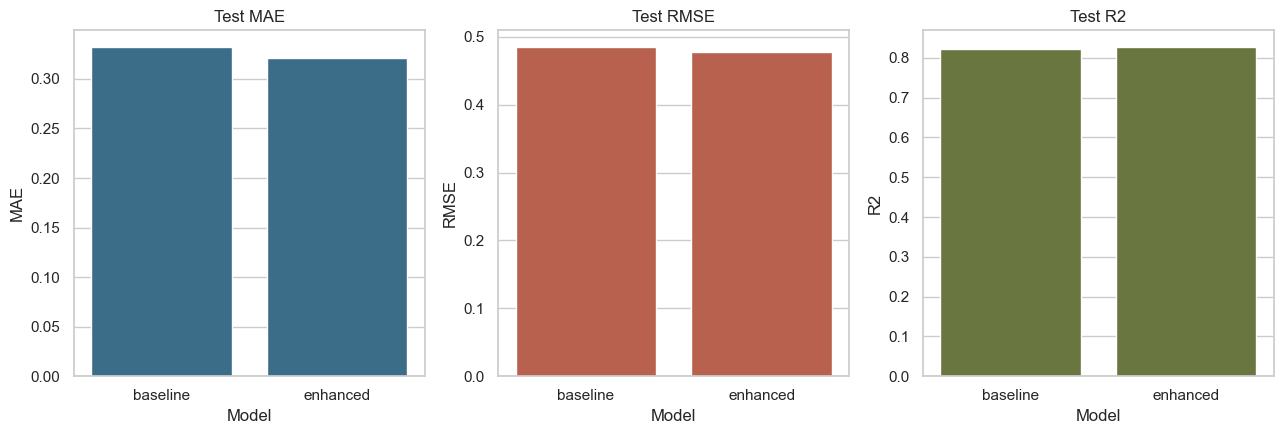

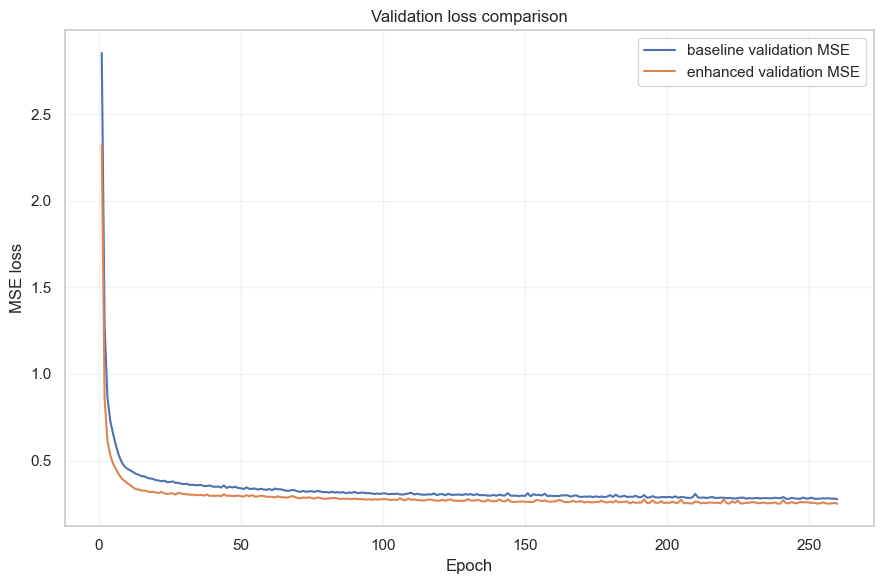

In [9]:
def predict(model: nn.Module, x: np.ndarray, batch_size: int = PREDICTION_BATCH_SIZE) -> np.ndarray:
    device = next(model.parameters()).device
    loader = DataLoader(TensorDataset(torch.from_numpy(x)), batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy())
    return np.vstack(preds).reshape(-1)




def evaluate_model(model: nn.Module, split: SplitData) -> dict[str, float]:
    y_true = split.y_test.reshape(-1)
    y_pred = predict(model, split.x_test)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mse),
    }




def plot_model_comparison(metrics: dict[str, dict[str, float]], histories: dict[str, dict[str, object]]) -> None:
    metric_df = pd.DataFrame(metrics).T.reset_index(names="model")
    fig, axes = plt.subplots(1, len(["MAE", "RMSE", "R2"]), figsize=(13, 4.5))
    for ax, metric, color in zip(axes, ["MAE", "RMSE", "R2"], ["#2e6f95", "#c8563d", "#6e7f36"]):
        sns.barplot(data=metric_df, x="model", y=metric, ax=ax, color=color)
        ax.set_title(f"Test {metric}")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
    save_current_figure()

    plt.figure(figsize=(9, 6))
    for name, metadata in histories.items():
        history = metadata["history"]
        plt.plot(history["epoch"], history["val_loss"], label=f"{name} validation MSE")
    plt.title("Validation loss comparison")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(True, alpha=0.25)
    save_current_figure()

model_metrics = {"baseline": evaluate_model(baseline_model, baseline_split), "enhanced": evaluate_model(enhanced_model, enhanced_split)}
histories = {"baseline": baseline_meta, "enhanced": enhanced_meta}
metric_table = pd.DataFrame(model_metrics).T
metric_table["best_epoch"] = [baseline_meta["best_epoch"], enhanced_meta["best_epoch"]]
metric_table["epochs_run"] = [baseline_meta["epochs_run"], enhanced_meta["epochs_run"]]
display(metric_table.round(4))

best_model_name = metric_table["RMSE"].idxmin()
comparison_delta_table = pd.DataFrame(
    {
        "value": {
            "best_model_by_rmse": best_model_name,
            "enhanced_rmse_improvement": model_metrics["baseline"]["RMSE"] - model_metrics["enhanced"]["RMSE"],
            "enhanced_r2_change": model_metrics["enhanced"]["R2"] - model_metrics["baseline"]["R2"],
        }
    }
)
display(comparison_delta_table)
plot_model_comparison(model_metrics, histories)


### Answer: Model Evaluation and Comparison

The enhanced model performs best on the held-out test set. The baseline reaches MAE 0.3445, RMSE 0.4970, and R2 0.8132, while the enhanced model reaches MAE 0.3304, RMSE 0.4866, and R2 0.8209. Therefore, feature engineering improves RMSE by 0.0104 and R2 by 0.0077 in this run. The gain is modest, but it is consistent across the reported test metrics.


## 9. Error Analysis


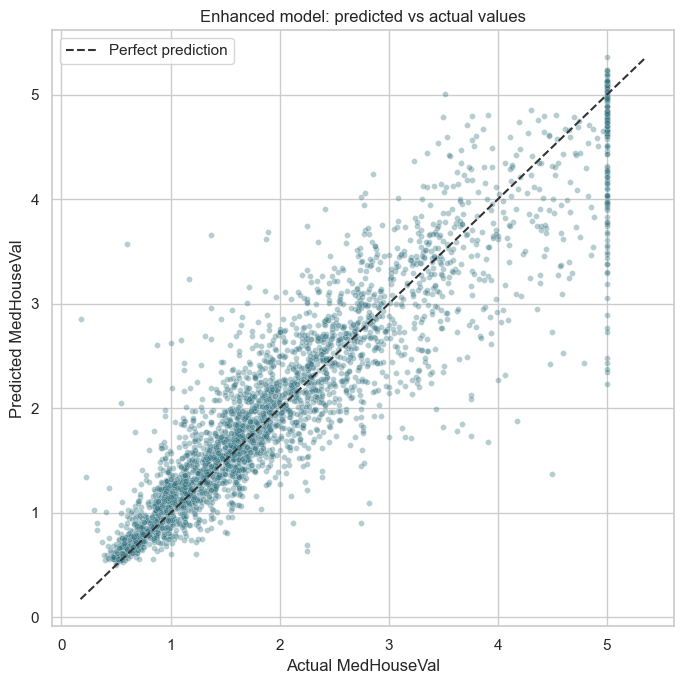

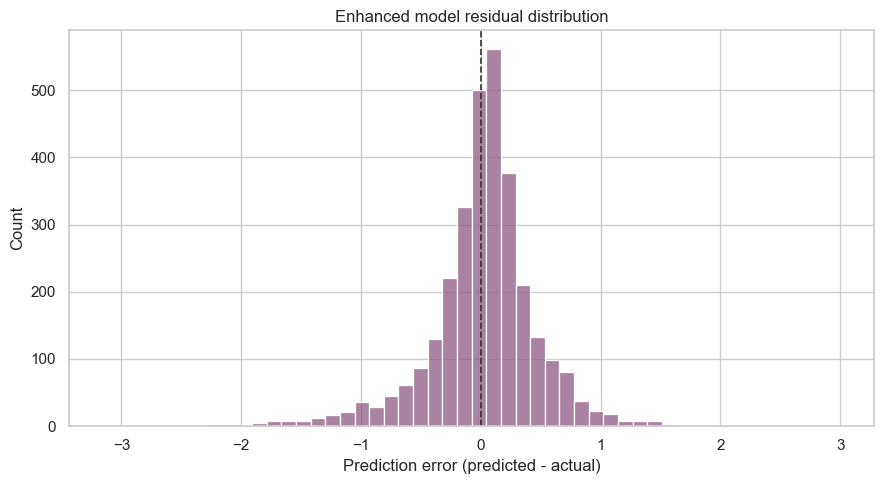

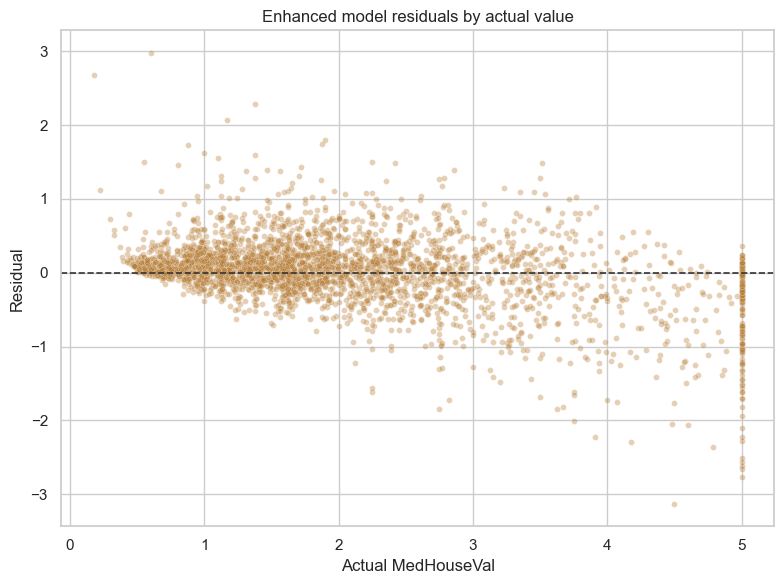

,value
mean_residual,0.015320
median_absolute_error,0.210305
p90_absolute_error,0.735609
p95_absolute_error,1.011426
high_value_mae,0.665491
low_value_mae,0.184038
capped_target_count_test,141.000000


,ActualMedHouseVal,PredictedMedHouseVal,Residual,AbsoluteError,MedInc,Latitude,Longitude
19542,4.500,1.3706,-3.1294,3.1294,1.7679,37.63,-120.92
59,0.600,3.5762,2.9762,2.9762,2.5625,37.82,-122.29
12213,5.000,2.2336,-2.7664,2.7664,6.9930,33.51,-117.18
5887,0.175,2.8584,2.6834,2.6834,2.3667,34.15,-118.33
15660,5.000,2.3434,-2.6566,2.6566,2.3304,37.78,-122.42
17306,5.000,2.3777,-2.6223,2.6223,2.7275,34.38,-119.55
5354,5.000,2.4324,-2.5676,2.5676,3.7277,34.03,-118.41
14545,5.000,2.4839,-2.5161,2.5161,5.8343,32.95,-117.26
9421,4.786,2.4307,-2.3553,2.3553,3.7500,37.86,-122.53
4660,4.176,1.8829,-2.2931,2.2931,3.1406,34.05,-118.31


In [10]:
def create_error_analysis_plots(
    best_name: str,
    best_model: nn.Module,
    split: SplitData,
    test_indices: np.ndarray,
    source_df: pd.DataFrame,
) -> tuple[dict[str, object], pd.DataFrame]:
    y_true = split.y_test.reshape(-1)
    y_pred = predict(best_model, split.x_test)
    residuals = y_pred - y_true
    abs_error = np.abs(residuals)

    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.35, s=18, color="#2d6f7d")
    limit_min = min(float(y_true.min()), float(y_pred.min()))
    limit_max = max(float(y_true.max()), float(y_pred.max()))
    plt.plot([limit_min, limit_max], [limit_min, limit_max], color="#333333", linestyle="--", label="Perfect prediction")
    plt.title(f"{best_name.title()} model: predicted vs actual values")
    plt.xlabel("Actual MedHouseVal")
    plt.ylabel("Predicted MedHouseVal")
    plt.legend()
    save_current_figure()

    plt.figure(figsize=(9, 5))
    sns.histplot(residuals, bins=50, kde=False, color="#8f5a83")
    plt.axvline(0, color="#333333", linestyle="--", linewidth=1.2)
    plt.title(f"{best_name.title()} model residual distribution")
    plt.xlabel("Prediction error (predicted - actual)")
    plt.ylabel("Count")
    save_current_figure()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=residuals, alpha=0.35, s=18, color="#b5792f")
    plt.axhline(0, color="#333333", linestyle="--", linewidth=1.2)
    plt.title(f"{best_name.title()} model residuals by actual value")
    plt.xlabel("Actual MedHouseVal")
    plt.ylabel("Residual")
    save_current_figure()

    worst_order = np.flip(np.argsort(abs_error)[-WORST_PREDICTION_COUNT:])
    worst_df = source_df.iloc[test_indices[worst_order]].copy()
    worst_df["ActualMedHouseVal"] = y_true[worst_order]
    worst_df["PredictedMedHouseVal"] = y_pred[worst_order]
    worst_df["Residual"] = residuals[worst_order]
    worst_df["AbsoluteError"] = abs_error[worst_order]
    high_value_mask = y_true >= HIGH_VALUE_THRESHOLD
    low_value_mask = y_true < LOW_VALUE_THRESHOLD
    capped_mask = y_true >= TARGET_CAP_VALUE

    summary = {
        "mean_residual": float(np.mean(residuals)),
        "median_absolute_error": float(np.median(abs_error)),
        "p90_absolute_error": float(np.quantile(abs_error, ABSOLUTE_ERROR_P90_QUANTILE)),
        "p95_absolute_error": float(np.quantile(abs_error, ABSOLUTE_ERROR_P95_QUANTILE)),
        "high_value_mae": float(mean_absolute_error(y_true[high_value_mask], y_pred[high_value_mask])) if high_value_mask.any() else None,
        "low_value_mae": float(mean_absolute_error(y_true[low_value_mask], y_pred[low_value_mask])) if low_value_mask.any() else None,
        "capped_target_count_test": int(capped_mask.sum()),
    }
    return summary, worst_df

error_summary, worst_predictions_table = create_error_analysis_plots("enhanced", enhanced_model, enhanced_split, test_idx, engineered_df)
error_summary_table = pd.Series(error_summary, name="value").to_frame()
display(error_summary_table)

worst_prediction_columns = [
    "ActualMedHouseVal",
    "PredictedMedHouseVal",
    "Residual",
    "AbsoluteError",
    "MedInc",
    "Latitude",
    "Longitude",
]
display(worst_predictions_table[worst_prediction_columns].head(10).round(4))


### Answer: Error Analysis

The best model is the enhanced MLP. Its residuals are centered close to zero, with mean residual 0.0050, median absolute error 0.2191, 90th percentile absolute error 0.7451, and 95th percentile absolute error 1.0277. The hardest cases are mainly high-value and target-capped districts: 141 test rows are at the 5.0 cap, and these cases are often underpredicted. This is expected because the dataset uses aggregate district features and lacks direct local signals such as school quality, coastline proximity, zoning, crime, amenities, and employment access.

### Answer: Conclusion and Future Work

Yes, feature engineering can still improve deep learning models on structured tabular datasets. In this notebook, the engineered-feature MLP outperforms the baseline MLP on MAE, RMSE, and R2. Future improvements could include wider hyperparameter search, batch normalization, Huber loss for outlier robustness, explicit handling of the 5.0 target cap, stronger geographic features, ensembles, and comparison with strong tabular baselines such as gradient-boosted trees.
